## Nonlinear-parameters Sampling First Strategy in Linear Inverse Problem (NonSLIP) forStatic Spin-Orbit Tomography (Type 1)

In this example, we marginalize over the high-dimensional linear parameters and first sample the nonlinear parameters using HMC-NUTS (NonSLIP; [Kawahara and Masuda 2020](https://arxiv.org/abs/2007.13096)
), thereby demonstrating full Bayesian modeling, including the map itself, for a Type-1 linear inverse problem (LIP).




In [1]:
%load_ext autoreload
%reload_ext autoreload
%matplotlib inline

## Generates a Ground Truth Map and Mock Light Curves

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from sot.core.weight import compute_weight 
np.random.seed(57)

In [3]:
# set geometry
inc = 45.0 / 180.0 * np.pi
Thetaeq = np.pi
# zeta=np.pi/3.0
zeta = 23.4 / 180.0 * np.pi
Pspin = 23.9344699 / 24.0  # Pspin: a sidereal day
wspin = 2 * np.pi / Pspin
Porb = 365.242190402
# Porb=40.0
worb = 2 * np.pi / Porb
Ni = 1024
obst = np.linspace(0.0, Porb, Ni)

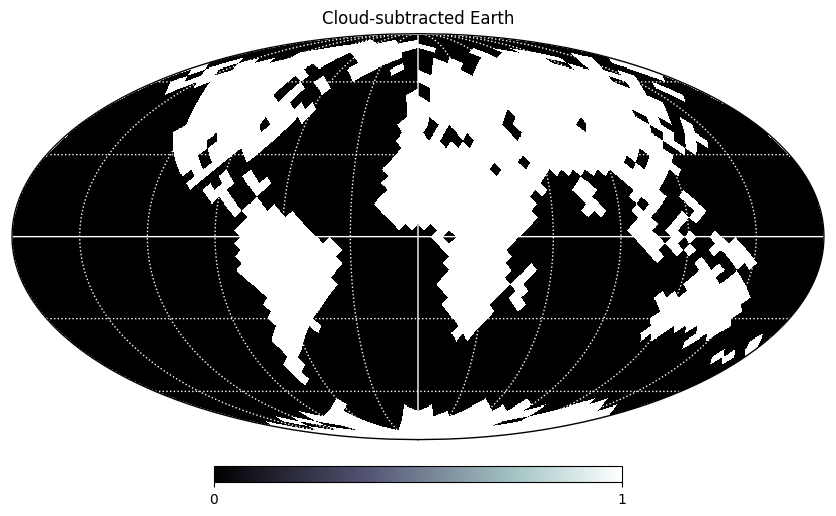

In [4]:
# test map
from sot.io.load_data import get_data_filepath
import matplotlib.pyplot as plt
nside = 16
npix = hp.nside2npix(nside)
file_path = get_data_filepath("mockalbedo16.fits")
mmap = hp.read_map(file_path)
mask = mmap > 0.0
mmap[mask] = 1.0
hp.mollview(
    mmap, title="Cloud-subtracted Earth", flip="geo", cmap=plt.cm.bone, min=0, max=1
)
# hp.mollview(Kvolall,title="Kvol",flip="geo",cmap=plt.cm.Spectral,min=-0.3,max=0.3)
hp.graticule(color="white")
M = len(mmap)
plt.savefig("mockalbedo16.png", dpi=300)

In [5]:
# generating light curve
from jaxinv.model.linear import type1
import jax.numpy as jnp
from sot.core.weight import compute_omega
Thetav = worb * obst
Phiv = np.mod(wspin * obst, 2 * np.pi)
omega = jnp.array(compute_omega(nside))
    
WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
geometric_weight = jnp.array(WV[:, :] * WI[:, :])
mmap = jnp.array(mmap)
lc = type1(geometric_weight, mmap)
#lc = np.dot(W, mmap)

sigma = np.mean(lc) * 0.05
noise = np.random.normal(0.0, sigma, len(lc))
lc = lc + noise

/tmp/ipykernel_103299/1021067397.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", prop={"size": 11}, frameon=False)


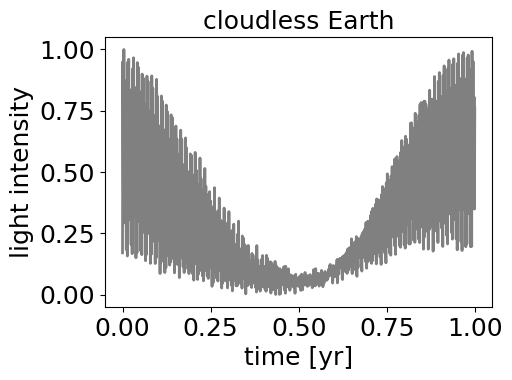

In [6]:
fig = plt.figure(figsize=(5, 3.5))
ax = fig.add_subplot(111)
ax.plot(obst / obst[-1], lc / np.max(lc), lw=2, color="gray")
plt.legend(loc="upper right", prop={"size": 11}, frameon=False)
plt.tick_params(labelsize=18)
plt.ylabel("light intensity", fontsize=18)
plt.xlabel("time [yr]", fontsize=18)
plt.title("cloudless Earth", fontsize=18)
plt.savefig("sotlc.png", bbox_inches="tight", pad_inches=0.0)
plt.show()

In [7]:
import matplotlib
fontsize=20
matplotlib.rcParams.update({'font.size':fontsize})

## Nonlinear parameters Sampling prior to solving the Linear Inverse Problem (NonSLIP)

In [8]:
from numpyro.infer import MCMC, NUTS
import numpyro
import numpyro.distributions as dist
from jax import random
from sot.core import sepmat 
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.meanmap import meanmap_inverse_type1
from jaxinv.bayes.weighted_kernel import grand_weighted_kernel_type1

/home/kawahara/anaconda3/envs/py310/lib/python3.10/site-packages/tqdm-4.66.5-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
Thetaeq = np.pi
zeta = 23.4 / 180.0 * np.pi
sep=sepmat.calc_sepmatrix(nside)

def model(y):
    #geometric weight
    cos_zeta = numpyro.sample('u', dist.Uniform(-1.0, 1.0))
    zeta = jnp.arccos(cos_zeta)
    numpyro.deterministic('zeta', zeta)
    Thetaeq = numpyro.sample('Thetaeq', dist.Uniform(0.0, 2*jnp.pi))
    WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
    geometric_weight = jnp.array(WV[:, :] * WI[:, :])
    
    #GP kernel
    alpha = numpyro.sample('alpha', dist.Exponential(1.0))
    #gamma = numpyro.sample('gamma', dist.Exponential(1.0)) #takes much longer time
    gamma=0.30
    Kernel_model_RBF=alpha*rbf(sep, gamma)

    #data noise
    sigma_d = numpyro.sample('sigma_d', dist.Exponential(1.0))
    #jitter = 1.e-6*jnp.eye(Kernel_model_RBF.shape[0]) #add a small jitter to Kernel_model_RBF if it's unstable
    kernel = sigma_d**2 * jnp.eye(len(y)) + grand_weighted_kernel_type1(geometric_weight, Kernel_model_RBF)  
    mu = jnp.zeros_like(y)
    numpyro.sample('y', dist.MultivariateNormal(mu, kernel), obs=y)

In [10]:
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
num_warmup, num_samples = 500, 1000
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_key_, y=lc)
mcmc.print_summary()

sample: 100%|██████████| 1500/1500 [03:30<00:00,  7.12it/s, 7 steps of size 7.66e-01. acc. prob=0.89] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
   Thetaeq      3.19      0.03      3.19      3.14      3.23    820.19      1.00
     alpha      0.23      0.05      0.23      0.14      0.31    813.42      1.00
   sigma_d      3.71      0.08      3.71      3.58      3.85   1011.96      1.00
         u      0.92      0.01      0.92      0.91      0.93    927.11      1.00

Number of divergences: 0


/home/kawahara/anaconda3/envs/py310/lib/python3.10/site-packages/arviz/plots/backends/matplotlib/pairplot.py:95: UserWarning: Argument reference_values does not include reference value for: alpha
  warnings.warn(


array([[<Axes: ylabel='zeta'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='Thetaeq'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='alpha'>, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='zeta', ylabel='sigma_d'>,
        <Axes: xlabel='Thetaeq'>, <Axes: xlabel='alpha'>,
        <Axes: xlabel='sigma_d'>]], dtype=object)

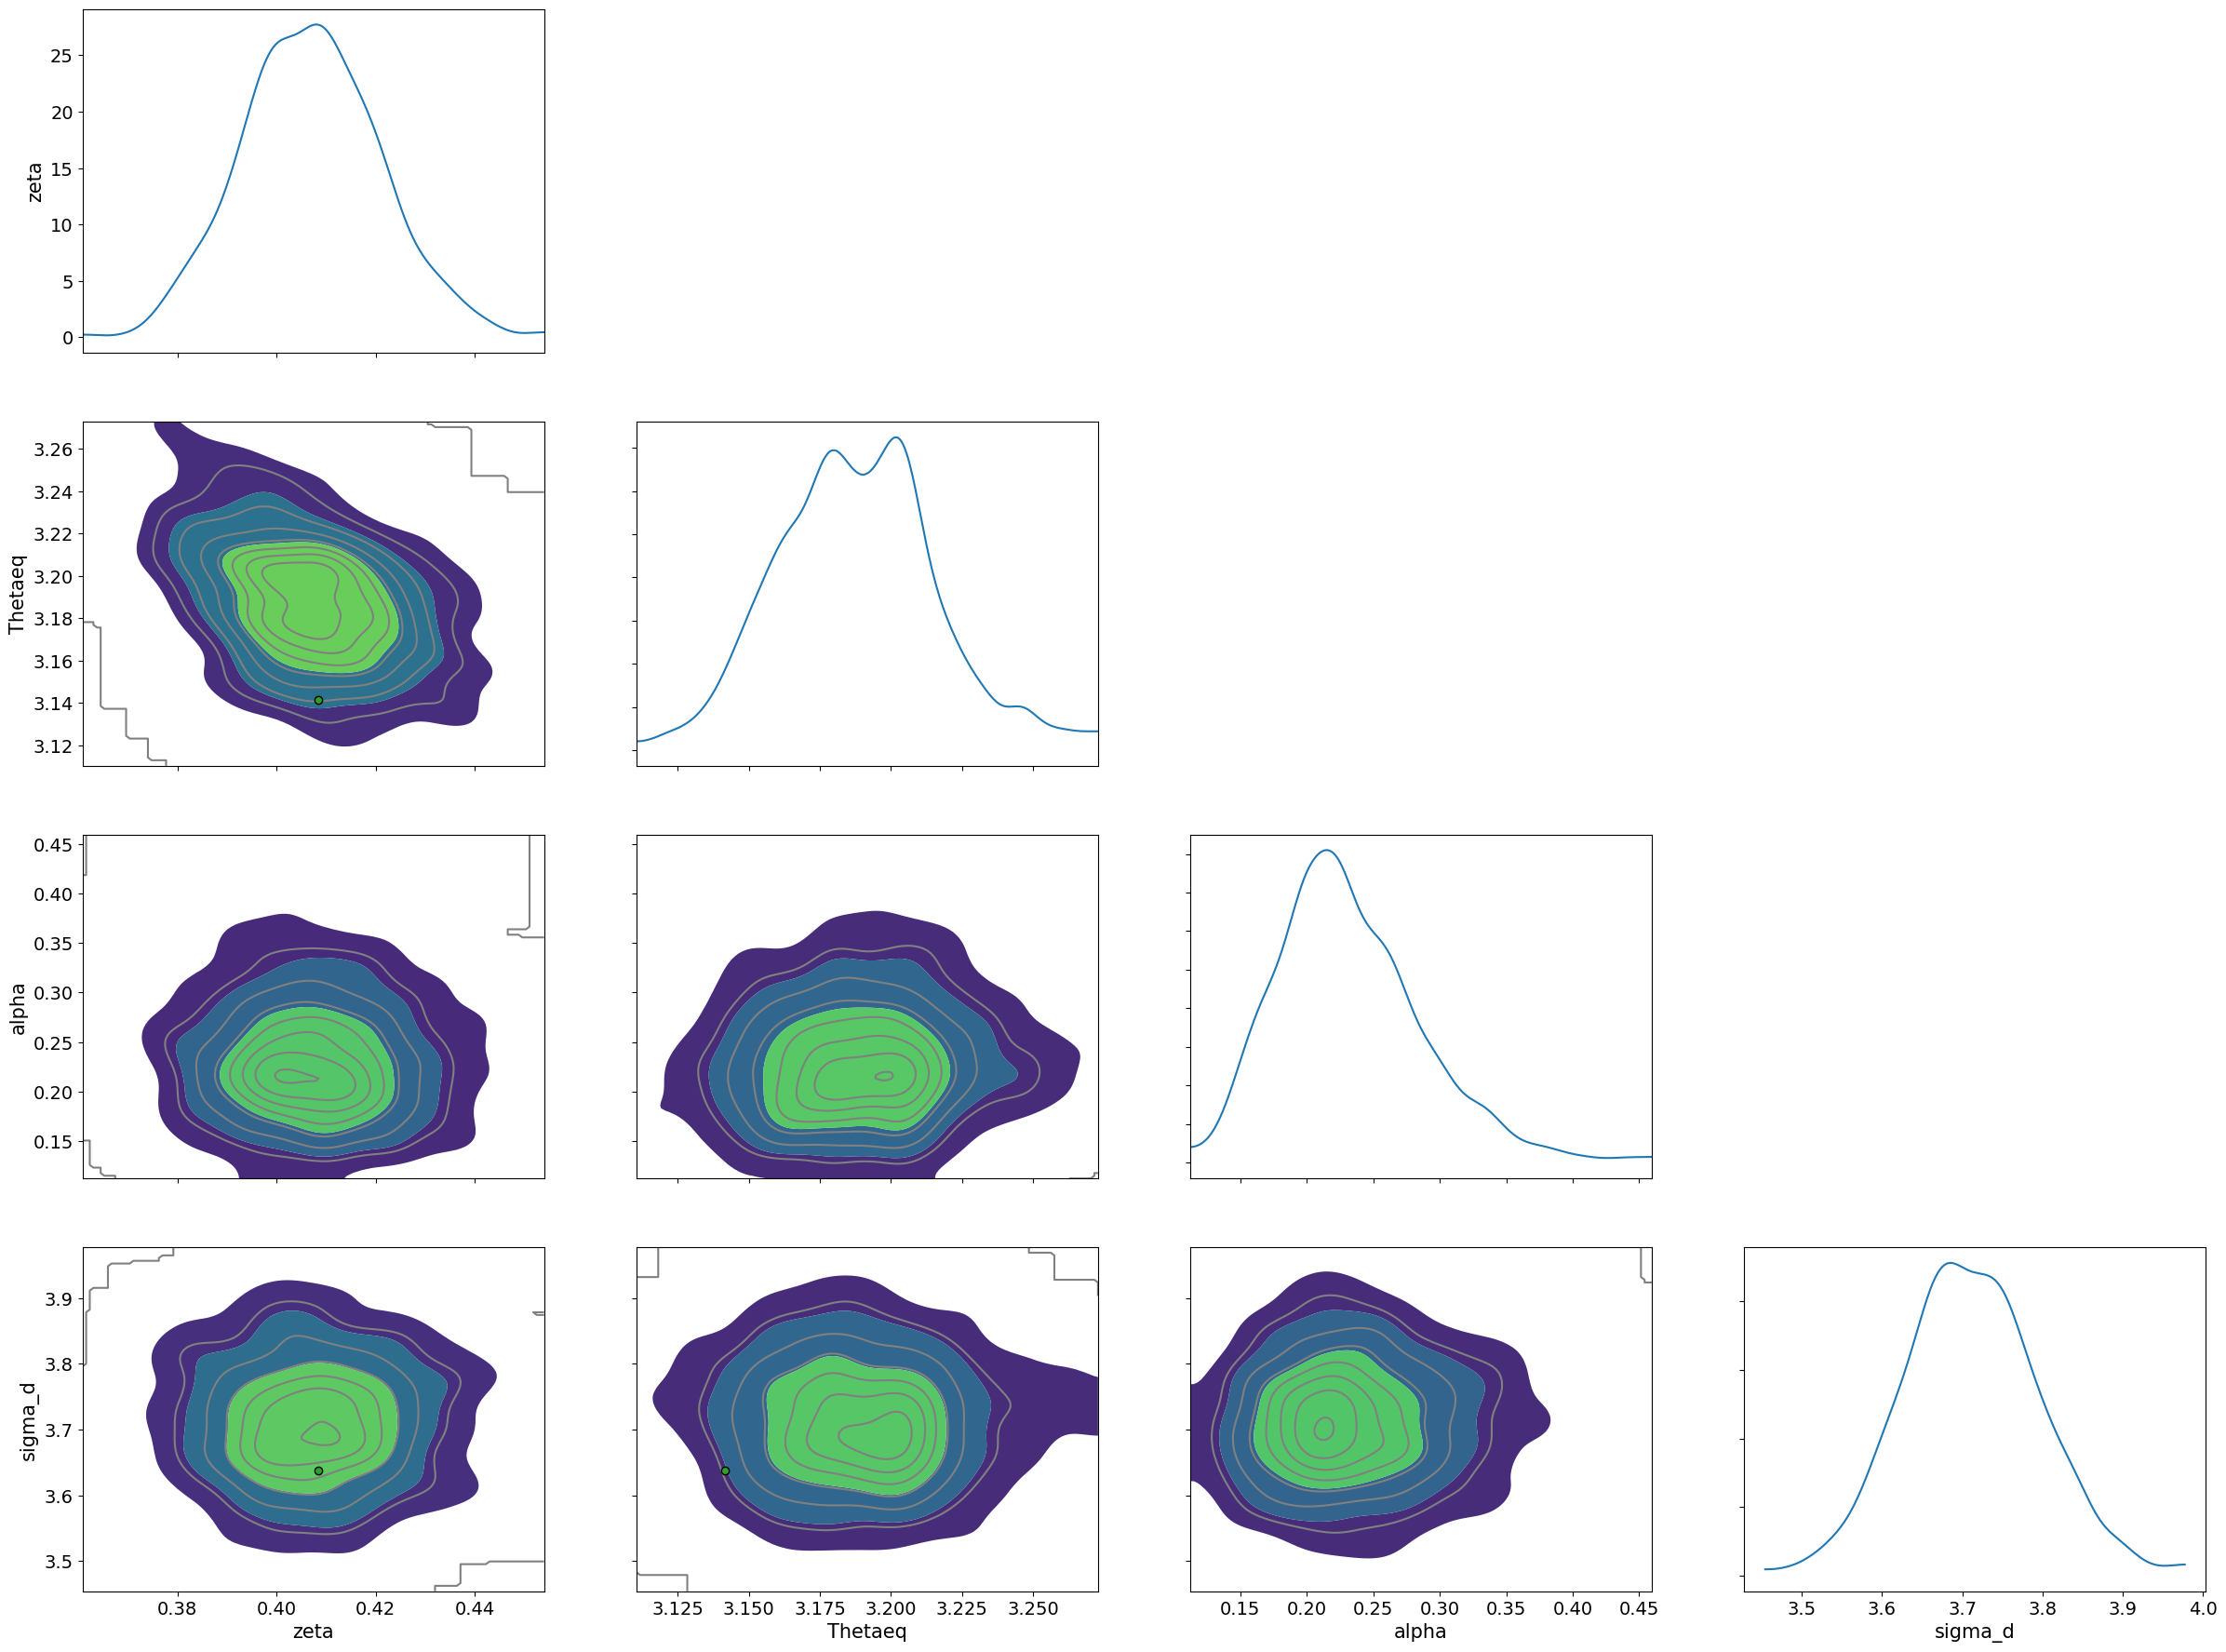

In [11]:
import arviz
pararr = ["zeta", "Thetaeq", "alpha","sigma_d"]
arviz.plot_pair(
    arviz.from_numpyro(mcmc),
    kind="kde",
    divergences=False,
    marginals=True,
    var_names=pararr,
    reference_values={"zeta": zeta, "Thetaeq": Thetaeq, "sigma_d": sigma},
)

## Draw a mean map

In [12]:
from tqdm import tqdm

posterior_sample = mcmc.get_samples()
mu = []
for i in tqdm(range(num_samples)):
    zeta_post = posterior_sample["zeta"][i]
    Thetaeq_post = posterior_sample["Thetaeq"][i]
    alpha_post = posterior_sample["alpha"][i]
    sigma_d_post = posterior_sample["sigma_d"][i]
    gamma=0.30
    Kernel_model_RBF=alpha_post*rbf(sep, gamma)
    precision_matrix = np.eye(len(lc))/sigma_d_post**2
    mu.append(meanmap_inverse_type1(geometric_weight, Kernel_model_RBF, precision_matrix, lc)) #Ks@W.T@lc

mu = jnp.array(mu)
mu_mean = jnp.mean(mu, axis=0)
mu_std = jnp.std(mu, axis=0)

100%|██████████| 1000/1000 [01:05<00:00, 15.38it/s]


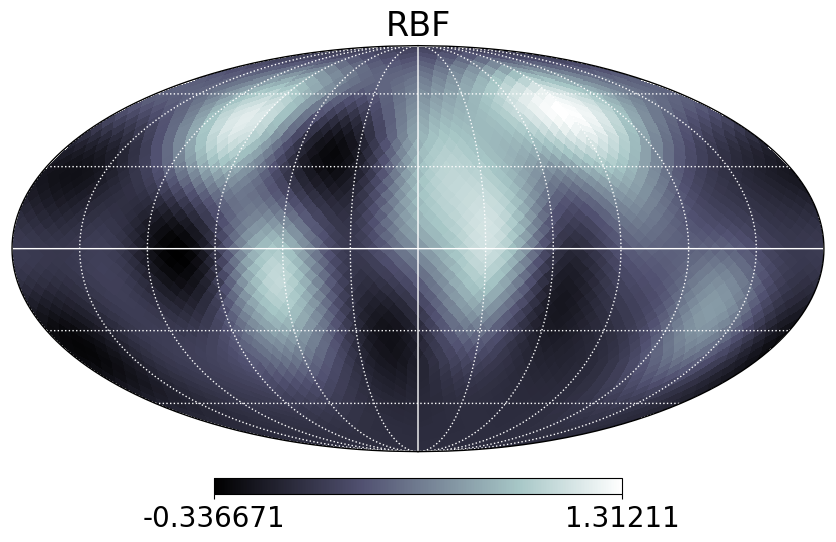

In [13]:
#best map
hp.mollview(mu_mean, title="RBF",flip="geo",cmap=plt.cm.bone)#,min=0,max=1.0)
hp.graticule(color="white");
plt.savefig("sotrbfmap.pdf", bbox_inches="tight", pad_inches=0.0);

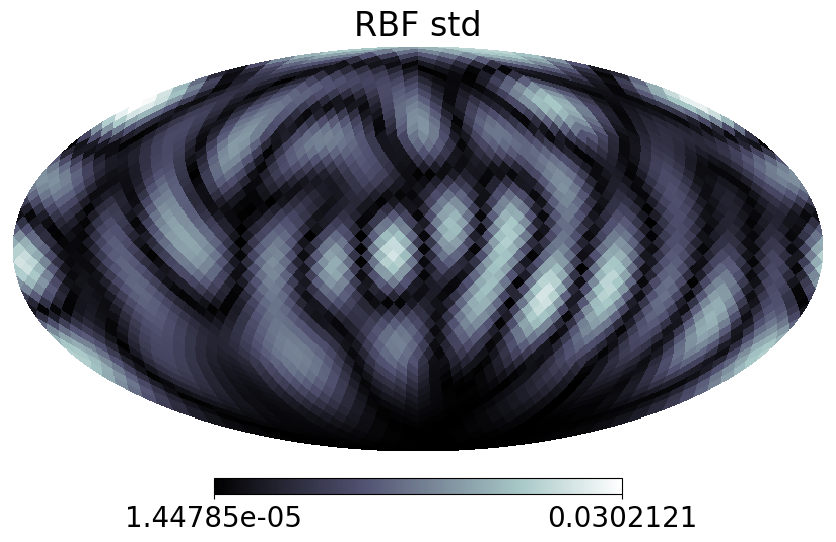

In [14]:
hp.mollview(mu_std, title="RBF std",flip="geo",cmap=plt.cm.bone)#,min=0,max=1.0)